In [1]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
path = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_decayAncestor_Spectrum/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))
det = 1

In [ ]:
branches = ['EventNum', 'PName', 'KE', 'Edep', 'Parent', 'Track', 'Time1', 'Time3', 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']

mczipFrame = CDataFrame(f"G4SimDir/mczip{det}", DMCfiles)
mczip = mczipFrame.AsNumpy(branches)

mcDecaysFrame = CDataFrame("G4SimDir/mcDecays", DMCfiles)
mcDecays = mcDecaysFrame.Filter(f'DetNum=={det}').AsNumpy(branches + ['decayAncestor.Process', 'decayAncestor.TrackID', 'decayAncestor.VolName'])

mcFluxCounterFrame = CDataFrame("G4SimDir/mcFluxCounter", DMCfiles)
mcFluxCounter = mcFluxCounterFrame.AsNumpy(branches + ['InOut'])

# Save array of events where neutron capture and Ge71 activation occurred. Determined by recoil/decay of Ga71 nucleus.
GeActivEvents = np.unique(mczipFrame.Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])

In [ ]:
# Select events in mczip and mcDecays which correspond to Ge activation
mcDecaysEventMask = np.isin(mcDecays['EventNum'], GeActivEvents)
mczipEventMask = np.isin(mczip['EventNum'], GeActivEvents)
mcFluxCounterEventMask = np.isin(mcFluxCounter['EventNum'], GeActivEvents)

# Process Ge activation data from mcDecays tree
for key in list(mcDecays.keys()):
    mcDecays[key] = mcDecays[key][mcDecaysEventMask]

# Process Ge activation data from mczip tree
for key in list(mczip.keys()):
    mczip[key] = mczip[key][mczipEventMask]

# Process Ge activation data from mcFluxCounter tree
for key in list(mcFluxCounter.keys()):
    mcFluxCounter[key] = mcFluxCounter[key][mcFluxCounterEventMask]

In [ ]:
mcDecaysTimeCut = (mcDecays['Time1'] < 5e16) & (mcDecays['Time1'] > 5e10)
mczipTimeCut = (mczip['Time1'] < 5e16) & (mczip['Time1'] > 5e10)
mcDecays['KEsum'] = np.array([mcDecays['KE'][(mcDecays['EventNum'] == event) & mcDecaysTimeCut].sum() for event in GeActivEvents])
mczip['Edepsum'] = np.array([mczip['Edep'][(mczip['EventNum'] == event) & mczipTimeCut].sum() for event in GeActivEvents])

In [6]:
fourColors = ['#3D6CA5', '#92C0DC', '#F9965C', '#D72B22']

(0.6842434566484082, 50000000.0)

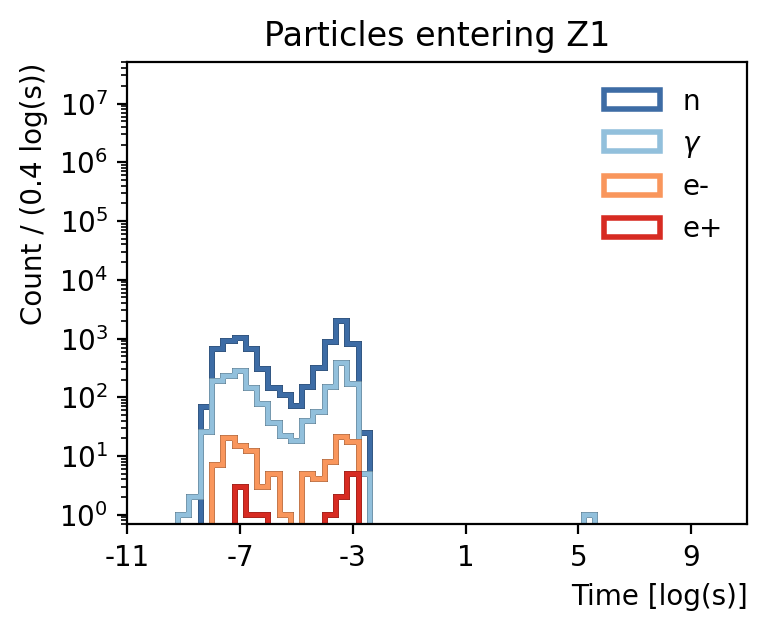

In [7]:
plt.figure(figsize=(4,3), dpi=200)
enterCut = mcFluxCounter['InOut'] == 1
Time_neutron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'neutron') & enterCut]*1e-9
Time_gamma = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'gamma') & enterCut]*1e-9
Time_electron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e-') & enterCut]*1e-9
Time_positron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e+') & enterCut]*1e-9
TimeBins = np.logspace(-10,10,51)

plt.hist(Time_neutron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_neutron, bins = TimeBins, label = 'n', histtype = 'step', lw = 2, color = fourColors[0])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, color = fourColors[1])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, color = fourColors[2])
plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, color = fourColors[3])

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.4 log(s))')
plt.title('Particles entering Z1')
plt.xscale('log')
plt.xticks([1e-11, 1e-7, 1e-3, 1e1, 1e5, 1e9], ['-11', '-7', '-3', '1', '5', '9'])
plt.yscale('log')
plt.legend()
plt.ylim(None, 5e7)

(0.6557450561815502, 50000000.0)

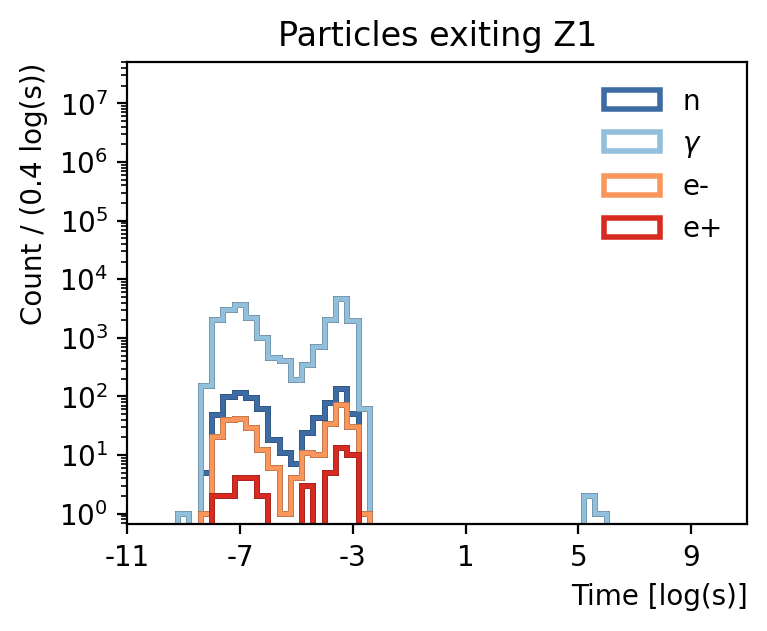

In [8]:
plt.figure(figsize=(4,3), dpi=200)
exitCut = mcFluxCounter['InOut'] == 2
Time_neutron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'neutron') & exitCut]*1e-9
Time_gamma = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'gamma') & exitCut]*1e-9
Time_electron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e-') & exitCut]*1e-9
Time_positron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e+') & exitCut]*1e-9
TimeBins = np.logspace(-10,10,51)

plt.hist(Time_neutron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_neutron, bins = TimeBins, label = 'n', histtype = 'step', lw = 2, color = fourColors[0])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, color = fourColors[1])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, color = fourColors[2])
plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black')
plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, color = fourColors[3])

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.4 log(s))')
plt.title('Particles exiting Z1')
plt.xscale('log')
plt.xticks([1e-11, 1e-7, 1e-3, 1e1, 1e5, 1e9], ['-11', '-7', '-3', '1', '5', '9'])
plt.yscale('log')
plt.legend()
plt.ylim(None, 5e7)

(0.5696729594254355, 500000000.0)

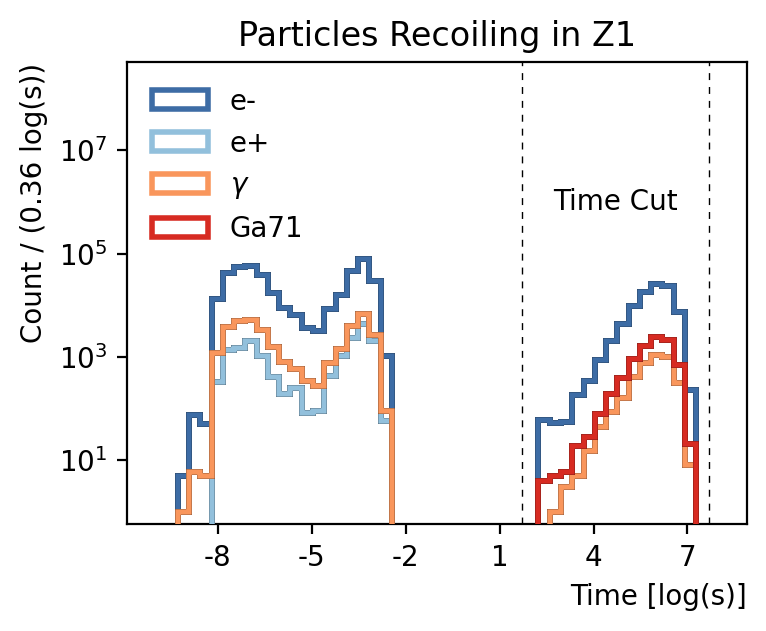

In [9]:
plt.figure(figsize=(4,3), dpi=200)
Time_electron = mczip['Time1'][mczip['PName'] == 'e-']*1e-9
Time_positron = mczip['Time1'][mczip['PName'] == 'e+']*1e-9
Time_gamma = mczip['Time1'][mczip['PName'] == 'gamma']*1e-9
Time_Ga71 = mczip['Time1'][mczip['PName'] == 'Ga71']*1e-9
TimeBins = np.logspace(-10,8, 51)

plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, zorder = 1, color = fourColors[0])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 0)
plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, zorder = 3, color = fourColors[1])
plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 2)
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, zorder = 5, color = fourColors[2])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 4)
plt.hist(Time_Ga71, bins = TimeBins, label = 'Ga71', histtype = 'step', lw = 2, zorder = 7, color = fourColors[3])
plt.hist(Time_Ga71, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 6)

plt.axvline(5e1, 0, 1, lw = 0.5, ls = (0, (5, 5)), color = 'black')
plt.axvline(5e7, 0, 1, lw = 0.5, ls = (0, (5, 5)), color = 'black')
plt.text(5e4, 1e6, 'Time Cut', ha = 'center', va = 'center', fontstretch='extra-expanded', weight = 550)

plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.36 log(s))')
plt.title('Particles Recoiling in Z1')
plt.xscale('log')
plt.xticks([1e-8, 1e-5, 1e-2, 1e1, 1e4, 1e7], ['-8', '-5', '-2', '1', '4', '7'])
plt.yscale('log')
plt.legend(loc = 'upper left')
plt.ylim(None, 5e8)

(0.5225474270323774, 500000000.0)

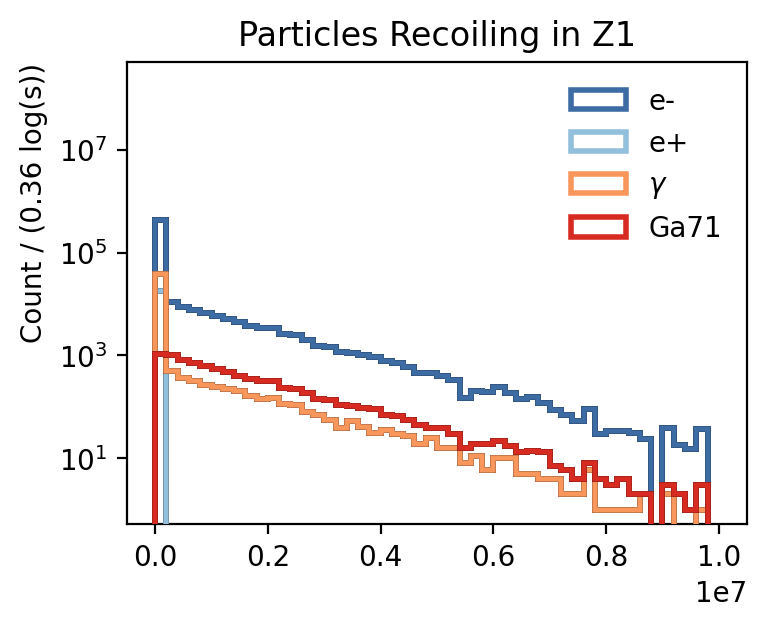

In [10]:
plt.figure(figsize=(4,3), dpi=200)
Time_electron = mczip['Time1'][mczip['PName'] == 'e-']*1e-9
Time_positron = mczip['Time1'][mczip['PName'] == 'e+']*1e-9
Time_gamma = mczip['Time1'][mczip['PName'] == 'gamma']*1e-9
Time_Ga71 = mczip['Time1'][mczip['PName'] == 'Ga71']*1e-9
TimeBins = np.linspace(0,1e7, 51)

plt.hist(Time_electron, bins = TimeBins, label = 'e-', histtype = 'step', lw = 2, zorder = 1, color = fourColors[0])
plt.hist(Time_electron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 0)
plt.hist(Time_positron, bins = TimeBins, label = 'e+', histtype = 'step', lw = 2, zorder = 3, color = fourColors[1])
plt.hist(Time_positron, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 2)
plt.hist(Time_gamma, bins = TimeBins, label = r'$\gamma$', histtype = 'step', lw = 2, zorder = 5, color = fourColors[2])
plt.hist(Time_gamma, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 4)
plt.hist(Time_Ga71, bins = TimeBins, label = 'Ga71', histtype = 'step', lw = 2, zorder = 7, color = fourColors[3])
plt.hist(Time_Ga71, bins = TimeBins, histtype = 'step', lw = 2.1, color = 'black', zorder = 6)

#plt.xlabel('Time [log(s)]')
plt.ylabel('Count / (0.36 log(s))')
plt.title('Particles Recoiling in Z1')
#plt.xscale('log')
#plt.xticks([1e-8, 1e-5, 1e-2, 1e1, 1e4, 1e7], ['-8', '-5', '-2', '1', '4', '7'])
plt.yscale('log')
plt.legend(loc = 'upper right')
plt.ylim(None, 5e8)

Text(0.5, 1.0, 'Total Recoil Energy / Event')

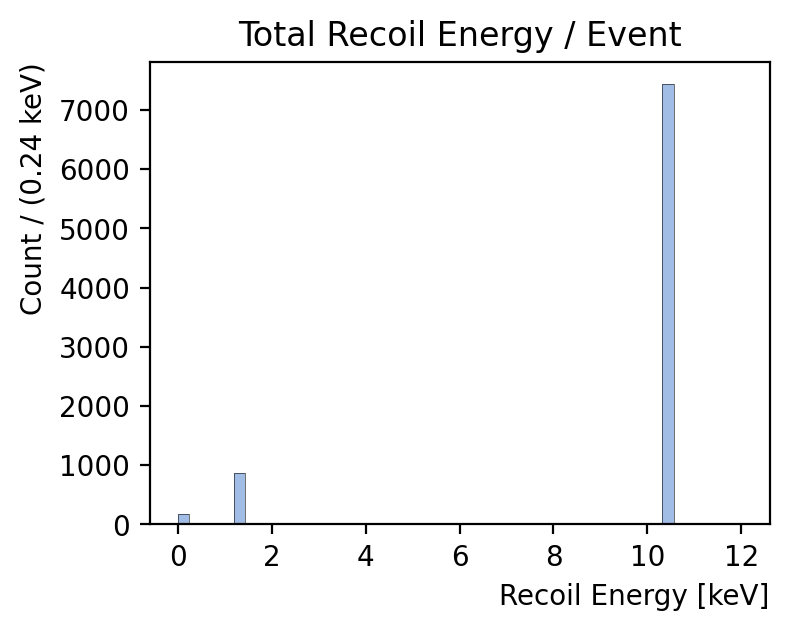

In [11]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, np.linspace(0, 12, 51), alpha = 1, color = 'C0')
plt.hist(mczip['Edepsum']*1e-3, np.linspace(0, 12, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.24 keV)')
plt.title('Total Recoil Energy / Event')

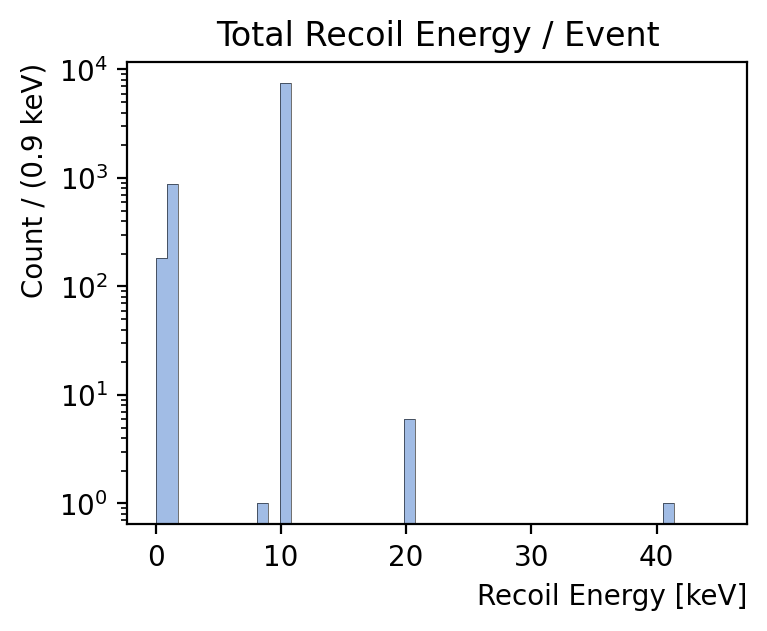

In [12]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 45, 51))
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 45, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.9 keV)')
plt.title('Total Recoil Energy / Event')
plt.yscale('log')

Text(0.5, 1.0, 'Total Decay Energy / Event')

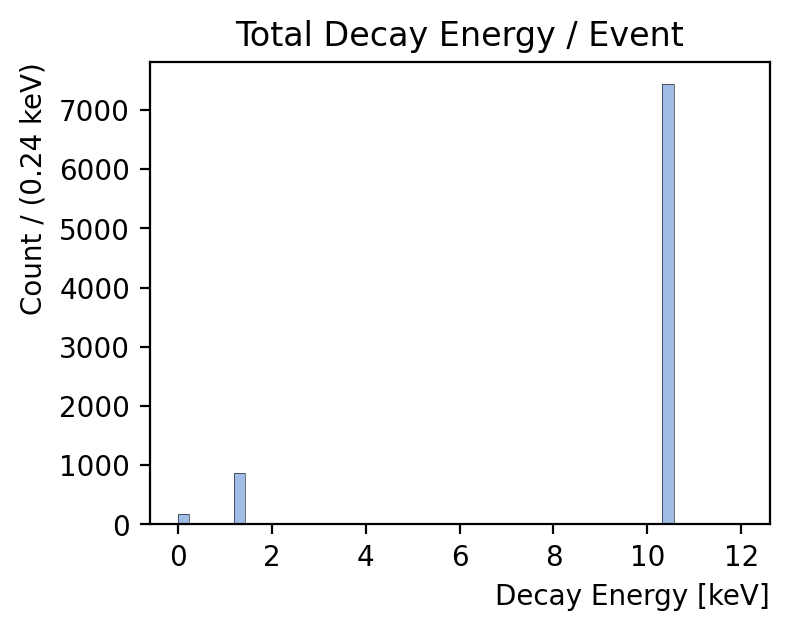

In [13]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3,  bins = np.linspace(0, 12, 51))
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.24 keV)')
plt.title('Total Decay Energy / Event')

In [30]:
GeActivEvents[(mcDecays['KEsum'] > 30e3)]

ndarray([79606609.])

In [31]:
mcDecays['PName'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]

ndarray(['e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-',
         'gamma', 'gamma', 'e-', 'Ga71', 'e-', 'e-', 'e-', 'e-', 'e-',
         'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-', 'e-'],
        dtype='<U15')

In [40]:
mcDecays['Time1'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]*1e-9

ndarray([3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123, 3084217.59152123, 3084217.59152123,
         3084217.59152123])

In [43]:
mcDecays['Time3'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]*1e-9*1.157e-5

ndarray([35.68439753, 35.68439753, 35.68439753, 35.68439753, 35.68439753,
         35.68439753, 35.68439753, 35.68439753, 35.68439753, 35.68439753,
         35.68439753, 35.68439753, 35.68439753, 35.68439753, 35.68439753,
         35.68439753, 35.68439753, 35.68439753, 35.68439753, 35.68439753,
         35.68439753, 35.68439753, 35.68439753, 35.68439753, 35.68439753,
         35.68439753, 35.68439753, 35.68439753, 35.68439753, 35.68439753,
         35.68439753])

In [32]:
mcDecays['decayAncestor.Process'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]

ndarray(['nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined'], dtype='<U41')

In [48]:
mczip['decayAncestor.Process'][(mczip['EventNum'] == 79606609.) & (mczipTimeCut)]

KeyError: 'decayAncestor.Process'

In [ ]:
mczip['Time3'][(mczip['EventNum'] == 79606609.) & (mczipTimeCut)]

In [47]:
mcDecays['decayAncestor.Process'][(mcDecays['EventNum'] == GeActivEvents[3]) & (mcDecaysTimeCut)]

ndarray(['nCapture/Undefined', 'nCapture/Undefined', 'nCapture/Undefined',
         'nCapture/Undefined'], dtype='<U41')

In [33]:
mcDecays['decayAncestor.PName'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]

ndarray(['Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71',
         'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71',
         'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71',
         'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71', 'Ge71'],
        dtype='<U15')

In [34]:
mcDecays['KE'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)] * 1e-3

ndarray([1.08019580e-02, 5.35513706e-02, 2.30863980e-02, 5.35365589e-02,
         5.67549540e-02, 8.57057017e-01, 1.02776487e+00, 9.07355826e-01,
         9.07389189e-01, 9.36861079e-01, 9.03654486e-01, 9.20901243e+00,
         9.18060403e+00, 8.08713047e+00, 3.74115189e-04, 1.08096854e-02,
         6.87075609e-02, 8.08685306e+00, 1.74866900e-02, 1.06759933e-02,
         5.30455757e-02, 1.06798724e-02, 1.06737017e-02, 1.06819858e-02,
         5.30501933e-02, 1.06866088e-02, 5.30507151e-02, 2.35930541e-02,
         7.19582354e-02, 5.30411631e-02, 5.35253091e-02])

In [35]:
mcDecays['decayAncestor.TrackID'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]

ndarray([67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67.,
         67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67.,
         67., 67., 67., 67., 67.])

In [36]:
mcDecays['Track'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]

ndarray([68., 83., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94., 95.,
         96., 98., 84., 81., 97., 69., 70., 71., 72., 73., 74., 75., 76.,
         77., 78., 79., 80., 82.])

In [37]:
mcDecays['decayAncestor.VolName'][(mcDecays['EventNum'] == 79606609.) & (mcDecaysTimeCut)]

ndarray(['Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip',
         'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip',
         'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip', 'Zip',
         'Zip', 'Zip', 'Zip', 'Zip'], dtype='<U20')

In [39]:
mcFluxCounterTimeCut = (mcFluxCounter['Time1'] < 5e16) & (mcFluxCounter['Time1'] > 5e10)
mcFluxCounter['PName'][(mcFluxCounter['EventNum'] == 79606609.) & (mcFluxCounter['InOut'] == 2) & mcFluxCounterTimeCut]

ndarray([], dtype='<U7')

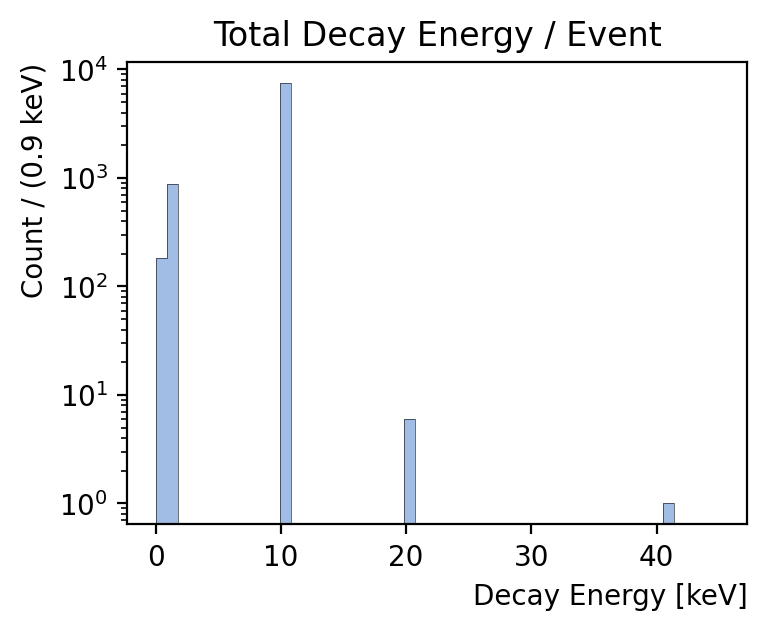

In [66]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 45, 51))
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 45, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.9 keV)')
plt.title('Total Decay Energy / Event')
plt.yscale('log')

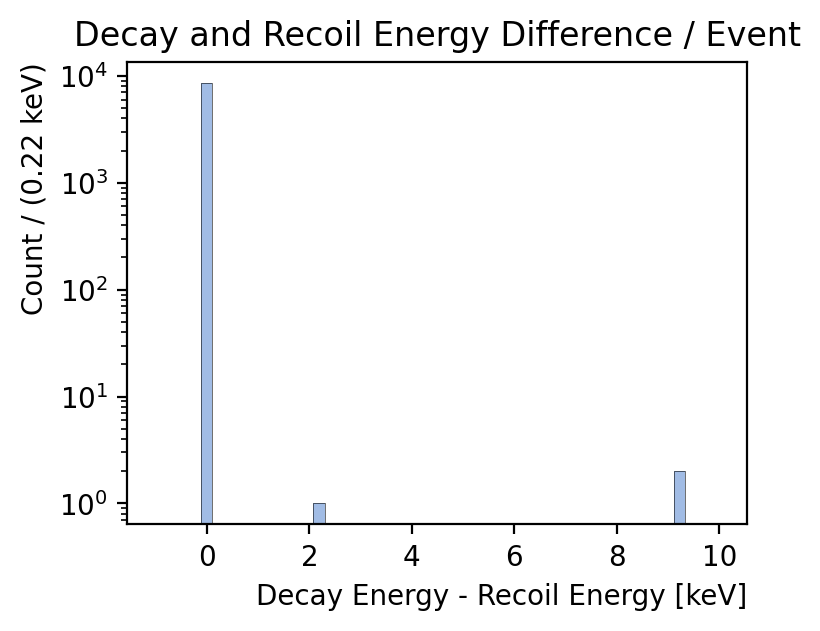

In [28]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = np.linspace(-1, 10, 51), alpha = 1)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = np.linspace(-1, 10, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy - Recoil Energy [keV]')
plt.ylabel('Count / (0.22 keV)')
plt.title('Decay and Recoil Energy Difference / Event')
plt.yscale('log')

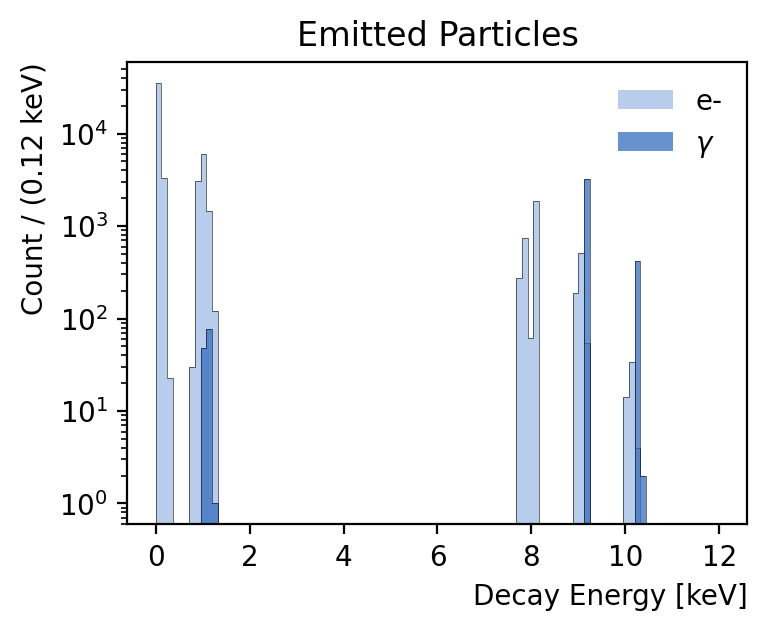

In [29]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KE'][(mcDecays['PName'] == 'e-') & mcDecaysTimeCut]*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 0, label = 'e-', color = 'C0')
plt.hist(mcDecays['KE'][(mcDecays['PName'] == 'e-') & mcDecaysTimeCut]*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 1)
plt.hist(mcDecays['KE'][(mcDecays['PName'] == 'gamma') & mcDecaysTimeCut]*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 2, label = r'$\gamma$', color = 'C2')
plt.hist(mcDecays['KE'][(mcDecays['PName'] == 'gamma') & mcDecaysTimeCut]*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 3)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.title('Emitted Particles')
plt.yscale('log')
plt.legend()

In [30]:
GeActivEvents[(mcDecays['KEsum']-mczip['Edepsum']) > 1000]

ndarray([48868184., 74448996., 93409793.])

In [38]:
mcFluxCounterFrame = CDataFrame("G4SimDir/mcFluxCounter", DMCfiles)
mcFluxCounter = mcFluxCounterFrame.Filter(f'EventNum=={48868184.} || EventNum=={74448996.} || EventNum=={93409793.}').AsNumpy(branches + ['InOut'] + ['decayAncestor.Process', 'KE3'])

In [39]:
mcFluxCounterTimeCut = (mcFluxCounter['Time1'] < 5e16) & (mcFluxCounter['Time1'] > 5e10)

In [40]:
mcFluxCounter['PName'][(mcFluxCounter['InOut'] == 2) & mcFluxCounterTimeCut]

ndarray(['gamma', 'gamma', 'gamma'], dtype='<U7')

In [41]:
mcFluxCounter['decayAncestor.PName'][(mcFluxCounter['InOut'] == 2) & mcFluxCounterTimeCut]

ndarray(['Ge71', 'Ge71', 'Ge71'], dtype='<U4')

In [42]:
mcFluxCounter['KE'][(mcFluxCounter['InOut'] == 2) & mcFluxCounterTimeCut]

ndarray([ 9208.99416052,  9208.9898414 , 10219.99163228])

In [53]:
mcFluxCounter['PName'][(mcFluxCounter['InOut'] == 1) & mcFluxCounterTimeCut]

ndarray(['gamma'], dtype='<U7')

In [54]:
mcFluxCounter['decayAncestor.PName'][(mcFluxCounter['InOut'] == 1) & mcFluxCounterTimeCut]

ndarray(['Ge71'], dtype='<U4')

In [55]:
mcFluxCounter['KE'][(mcFluxCounter['InOut'] == 1) & mcFluxCounterTimeCut]

ndarray([8005.71])

In [57]:
mcFluxCounter['EventNum'][(mcFluxCounter['InOut'] == 1) & mcFluxCounterTimeCut]

ndarray([93409793.])